**GRAFICAS A PARTIR DE INDICADORES ECONOMICOS**

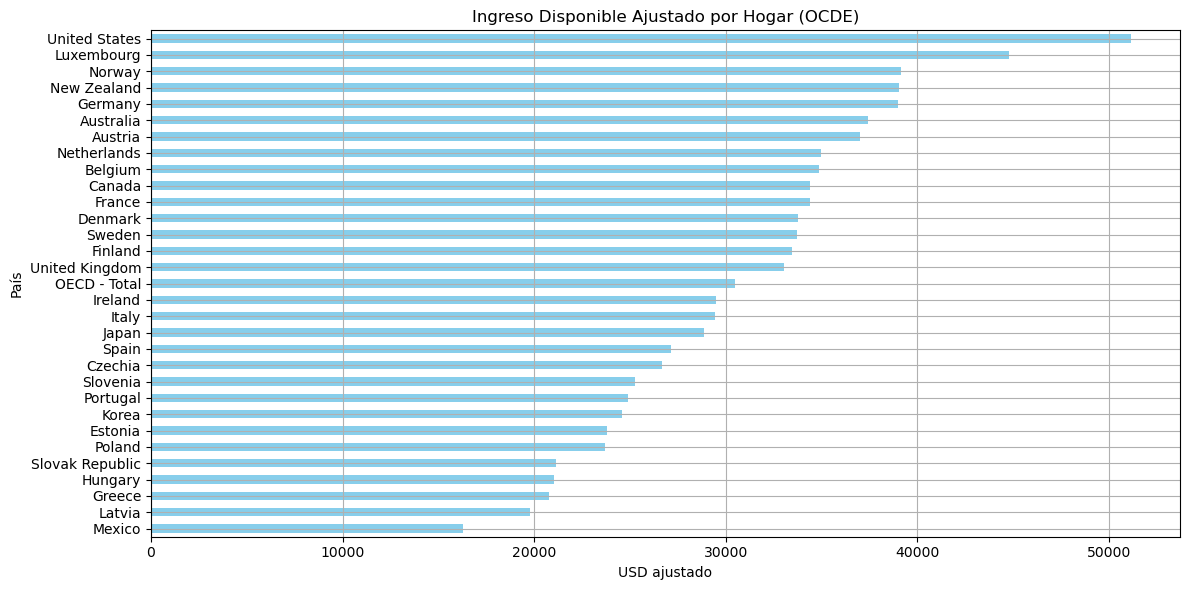

In [20]:
import pandas as pd
import matplotlib.pyplot as plt


df_csv = pd.read_csv("OECD,DF_BLI,+all.csv")
indicadores_interes = ["Household net adjusted disposable income",  "Employment rate","Labour market insecurity", "Air pollution","Life expectancy"]
df_filtrado = df_csv[df_csv["Indicator"].isin(indicadores_interes)]
df_filtrado = df_filtrado[["Country", "Indicator", "OBS_VALUE"]]
df_promedios = df_filtrado.groupby(["Country", "Indicator"])["OBS_VALUE"].mean().reset_index()
df_pivot = df_promedios.pivot(index="Country", columns="Indicator", values="OBS_VALUE").dropna()

plt.figure(figsize=(12, 6))
df_pivot["Household net adjusted disposable income"].sort_values().plot(kind="barh", color='skyblue')
plt.title("Ingreso Disponible Ajustado por Hogar (OCDE)")
plt.xlabel("USD ajustado")
plt.ylabel("País")
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
nuevos_indicadores = ["Personal earnings","Household net adjusted disposable income","Life satisfaction","Years in education","Student skills","Household net adjusted disposable income","Life satisfaction"]
df_nuevos = df_csv[df_csv["Indicator"].isin(nuevos_indicadores)]
df_nuevos = df_nuevos[["Country", "Indicator", "OBS_VALUE"]]
df_nuevos_avg = df_nuevos.groupby(["Country", "Indicator"])["OBS_VALUE"].mean().reset_index()

# Reorganizar a formato ancho
df_nuevos_pivot = df_nuevos_avg.pivot(index="Country", columns="Indicator", values="OBS_VALUE").dropna()

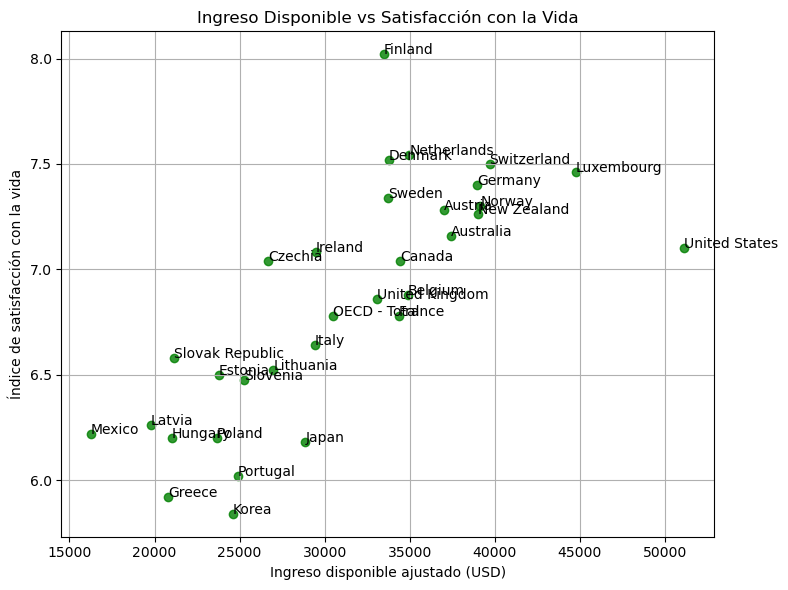

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_nuevos_pivot["Household net adjusted disposable income"],
    df_nuevos_pivot["Life satisfaction"],
    alpha=0.8,
    color='green'
)
for country in df_nuevos_pivot.index:
    plt.text(
        df_nuevos_pivot.loc[country, "Household net adjusted disposable income"],
        df_nuevos_pivot.loc[country, "Life satisfaction"],
        country, fontsize=10
    )
plt.title("Ingreso Disponible vs Satisfacción con la Vida")
plt.xlabel("Ingreso disponible ajustado (USD)")
plt.ylabel("Índice de satisfacción con la vida")
plt.grid(True)
plt.tight_layout()
plt.show()


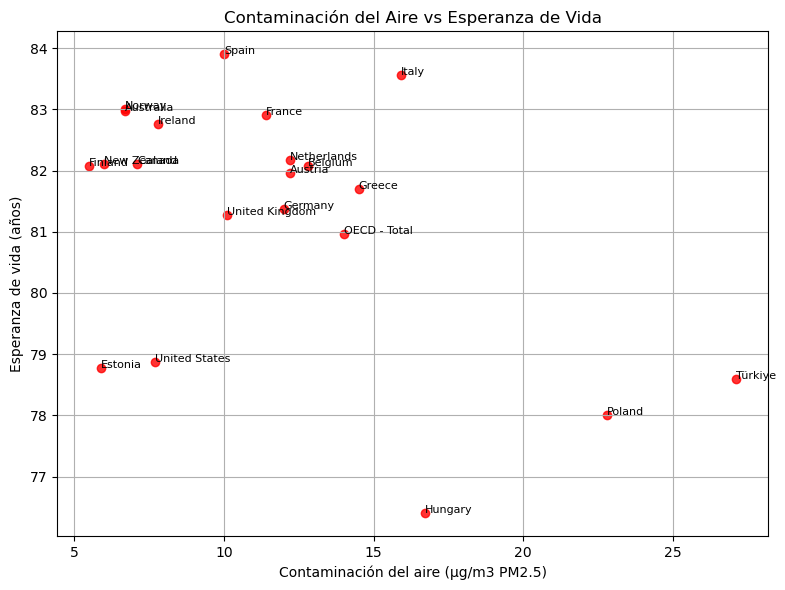

In [27]:
indicadores_extra = ["Self-reported health","Life expectancy", "Air pollution","Employees working very long hours", "Time devoted to leisure and personal care" ]

# Filtrar, limpiar y agrupar los datos
df_extra = df_csv[df_csv["Indicator"].isin(indicadores_extra)]
df_extra = df_extra[["Country", "Indicator", "OBS_VALUE"]]
df_extra_avg = df_extra.groupby(["Country", "Indicator"])["OBS_VALUE"].mean().reset_index()

# Convertir a formato ancho
df_extra_pivot = df_extra_avg.pivot(index="Country", columns="Indicator", values="OBS_VALUE").dropna()
plt.figure(figsize=(8, 6))
plt.scatter(
    df_extra_pivot["Air pollution"],
    df_extra_pivot["Life expectancy"],
    alpha=0.8,
    color='red'
)
for country in df_extra_pivot.index:
    plt.text(
        df_extra_pivot.loc[country, "Air pollution"],
        df_extra_pivot.loc[country, "Life expectancy"],
        country, fontsize=8
    )
plt.title("Contaminación del Aire vs Esperanza de Vida")
plt.xlabel("Contaminación del aire (µg/m3 PM2.5)")
plt.ylabel("Esperanza de vida (años)")
plt.grid(True)
plt.tight_layout()
plt.show()